# Iris MLP분류 연습

In [ ]:
'''
**Iris 데이터셋은 총 150개(샘플 150개)**가 맞아!

정확하게는:

Setosa: 50개

Versicolor: 50개

Virginica: 50개

총합 150개

입력 특징(feature)은 4개:

꽃받침 길이 (sepal length)

꽃받침 너비 (sepal width)

꽃잎 길이 (petal length)

꽃잎 너비 (petal width)

레이블 값(y)은 0, 1, 2로 되어 있어:

0: Setosa

1: Versicolor

2: Virginica
'''


================ 임베딩 벡터 (전체 150개) ================
Shape: torch.Size([150, 4])
tensor([[-9.0068e-01,  1.0190e+00, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00, -1.3198e-01, -1.3402e+00, -1.3154e+00],
        [-1.3854e+00,  3.2841e-01, -1.3971e+00, -1.3154e+00],
        [-1.5065e+00,  9.8217e-02, -1.2834e+00, -1.3154e+00],
        [-1.0218e+00,  1.2492e+00, -1.3402e+00, -1.3154e+00],
        [-5.3718e-01,  1.9398e+00, -1.1697e+00, -1.0522e+00],
        [-1.5065e+00,  7.8881e-01, -1.3402e+00, -1.1838e+00],
        [-1.0218e+00,  7.8881e-01, -1.2834e+00, -1.3154e+00],
        [-1.7489e+00, -3.6218e-01, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00,  9.8217e-02, -1.2834e+00, -1.4471e+00],
        [-5.3718e-01,  1.4794e+00, -1.2834e+00, -1.3154e+00],
        [-1.2642e+00,  7.8881e-01, -1.2266e+00, -1.3154e+00],
        [-1.2642e+00, -1.3198e-01, -1.3402e+00, -1.4471e+00],
        [-1.8700e+00, -1.3198e-01, -1.5107e+00, -1.4471e+00],
        [-5.2506e-02,  2.1700e+00, -1.4539e+00, -1.3

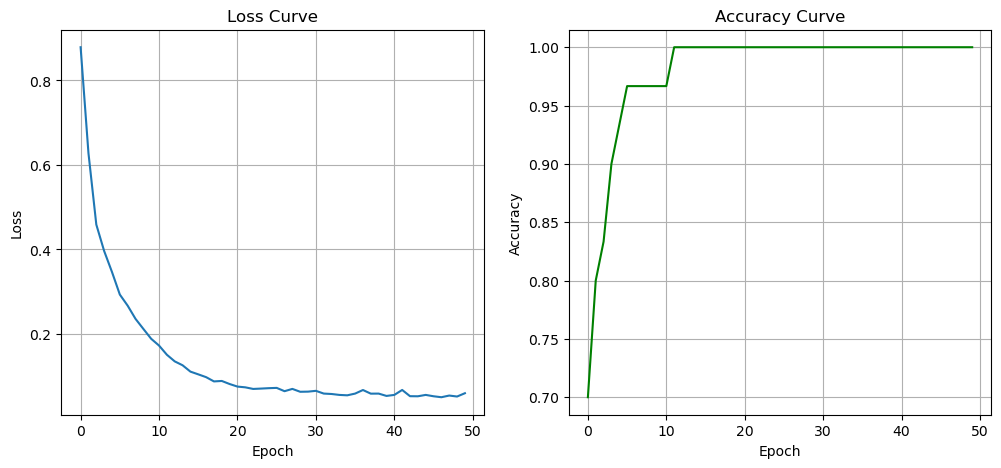

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ===================================
#      실험 로그 저장 리스트
# ===================================
experiment_logs = []

# ===================================
#      MLP 모델 클래스
# ===================================
class MLP(nn.Module):
    def __init__(self, hidden_units=16, activation="relu"):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        elif activation == "tanh":
            act = nn.Tanh()
        elif activation == "sigmoid":
            act = nn.Sigmoid()
        else:
            raise ValueError("activation 은 relu/tanh/sigmoid 중 하나여야 합니다.")

        self.net = nn.Sequential(
            nn.Linear(4, hidden_units),
            act,
            nn.Linear(hidden_units, 3)
        )

    def forward(self, x):
        return self.net(x)


# ===================================
#       실험 실행 함수
# ===================================
def run_experiment(hidden_units=16, batch_size=16, lr=0.01, 
                   epochs=50, activation="relu", show_graph=True,
                   show_embedding=None):
    """
    show_embedding 옵션:
        None  → 직접 실행 시 True, import 사용 시 False
        True  → 무조건 출력
        False → 무조건 출력 X
    """

    # ================
    # 임베딩 출력 여부 결정
    # ================
    if show_embedding is None:
        # 직접 실행인지(import가 아닌지) 자동 판단
        show_embedding = (__name__ == "__main__")

    # ================
    # 데이터 준비
    # ================
    iris = load_iris()
    X = iris.data
    y = iris.target

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    # ============================================
    #   전체 임베딩 벡터 출력 (조건부)
    # ============================================
    if show_embedding:
        print("\n================ 임베딩 벡터 (전체 150개) ================")
        print(f"Shape: {X.shape}")
        print(X)
        print("========================================================\n")

    # ================
    # Train/Test Split
    # ================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    train_loader = DataLoader(
        TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False
    )

    # ================
    # 모델 / 옵티마이저
    # ================
    model = MLP(hidden_units, activation)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_accuracies = []

    # ================
    #   Training
    # ================
    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # --- Test Accuracy ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb)
                _, pred_cls = torch.max(preds, 1)
                correct += (pred_cls == yb).sum().item()
                total += yb.size(0)

        test_acc = correct / total
        test_accuracies.append(test_acc)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1}/{epochs} Loss={avg_loss:.4f} Acc={test_acc:.4f}")

    # ================
    #   실험 결과 저장
    # ================
    exp = {
        "hidden_units": hidden_units,
        "batch_size": batch_size,
        "learning_rate": lr,
        "epochs": epochs,
        "activation": activation,
        "final_loss": train_losses[-1],
        "final_accuracy": test_accuracies[-1]
    }
    experiment_logs.append(exp)

    print("\n===== 실험 결과 =====")
    print(exp)
    print("=====================\n")

    # ================
    #   그래프 출력
    # ================
    if show_graph:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(train_losses)
        plt.title("Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(test_accuracies, color="green")
        plt.title("Accuracy Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(True)

        plt.show()

    return exp


# ===================================
#   직접 실행 시 자동 출력
# ===================================
if __name__ == "__main__":
    run_experiment()


In [ ]:
# e에 관한 뜻
'''
 과학적 표기	   의미	          실제 값
-9.0068e-01	-9.0068 × 10⁻¹	-0.90068
1.0190e+00	1.0190 × 10⁰	1.0190
-1.3402e+00	-1.3402 × 10⁰	-1.3402
-1.3154e+00	-1.3154 × 10⁰	-1.3154
3.2841e-01	3.2841 × 10⁻¹	0.32841
9.8217e-02	0.098217 × 10⁰	0.098217
'''

# 학습 데이터에 대한 정보

🌸 Setosa (label=0)
평균(mean)

Sepal Length: 5.006

Sepal Width: 3.418

Petal Length: 1.464

Petal Width: 0.244

표준편차(std)

Sepal Length: 0.352

Sepal Width: 0.381

Petal Length: 0.173

Petal Width: 0.107

🌿 Versicolor (label=1)
평균(mean)

Sepal Length: 5.936

Sepal Width: 2.770

Petal Length: 4.260

Petal Width: 1.326

표준편차(std)

Sepal Length: 0.516

Sepal Width: 0.314

Petal Length: 0.470

Petal Width: 0.198

🌹 Virginica (label=2)
평균(mean)

Sepal Length: 6.588

Sepal Width: 2.974

Petal Length: 5.552

Petal Width: 2.026

표준편차(std)

Sepal Length: 0.636

Sepal Width: 0.322

Petal Length: 0.552

Petal Width: 0.275


================ 임베딩 벡터 (전체 150개) ================
Shape: torch.Size([150, 4])
tensor([[-9.0068e-01,  1.0190e+00, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00, -1.3198e-01, -1.3402e+00, -1.3154e+00],
        [-1.3854e+00,  3.2841e-01, -1.3971e+00, -1.3154e+00],
        [-1.5065e+00,  9.8217e-02, -1.2834e+00, -1.3154e+00],
        [-1.0218e+00,  1.2492e+00, -1.3402e+00, -1.3154e+00],
        [-5.3718e-01,  1.9398e+00, -1.1697e+00, -1.0522e+00],
        [-1.5065e+00,  7.8881e-01, -1.3402e+00, -1.1838e+00],
        [-1.0218e+00,  7.8881e-01, -1.2834e+00, -1.3154e+00],
        [-1.7489e+00, -3.6218e-01, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00,  9.8217e-02, -1.2834e+00, -1.4471e+00],
        [-5.3718e-01,  1.4794e+00, -1.2834e+00, -1.3154e+00],
        [-1.2642e+00,  7.8881e-01, -1.2266e+00, -1.3154e+00],
        [-1.2642e+00, -1.3198e-01, -1.3402e+00, -1.4471e+00],
        [-1.8700e+00, -1.3198e-01, -1.5107e+00, -1.4471e+00],
        [-5.2506e-02,  2.1700e+00, -1.4539e+00, -1.3

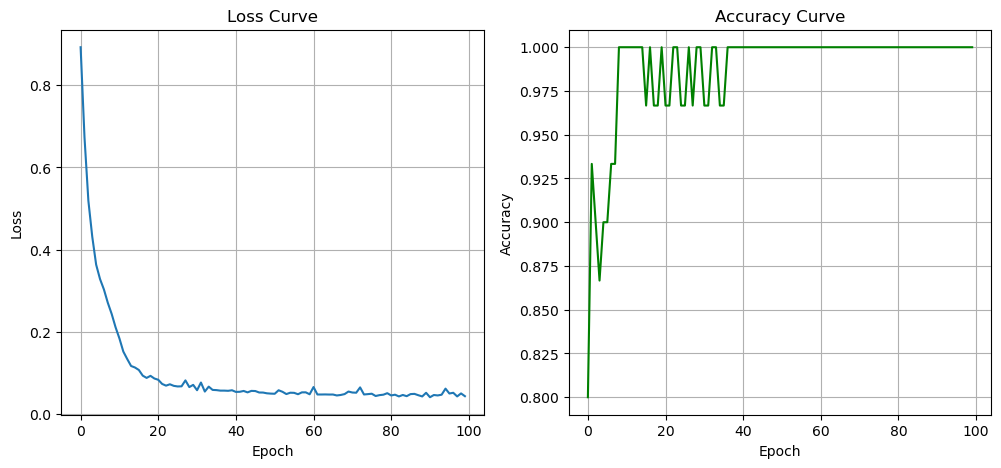


================ 임베딩 벡터 (전체 150개) ================
Shape: torch.Size([150, 4])
tensor([[-9.0068e-01,  1.0190e+00, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00, -1.3198e-01, -1.3402e+00, -1.3154e+00],
        [-1.3854e+00,  3.2841e-01, -1.3971e+00, -1.3154e+00],
        [-1.5065e+00,  9.8217e-02, -1.2834e+00, -1.3154e+00],
        [-1.0218e+00,  1.2492e+00, -1.3402e+00, -1.3154e+00],
        [-5.3718e-01,  1.9398e+00, -1.1697e+00, -1.0522e+00],
        [-1.5065e+00,  7.8881e-01, -1.3402e+00, -1.1838e+00],
        [-1.0218e+00,  7.8881e-01, -1.2834e+00, -1.3154e+00],
        [-1.7489e+00, -3.6218e-01, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00,  9.8217e-02, -1.2834e+00, -1.4471e+00],
        [-5.3718e-01,  1.4794e+00, -1.2834e+00, -1.3154e+00],
        [-1.2642e+00,  7.8881e-01, -1.2266e+00, -1.3154e+00],
        [-1.2642e+00, -1.3198e-01, -1.3402e+00, -1.4471e+00],
        [-1.8700e+00, -1.3198e-01, -1.5107e+00, -1.4471e+00],
        [-5.2506e-02,  2.1700e+00, -1.4539e+00, -1.3

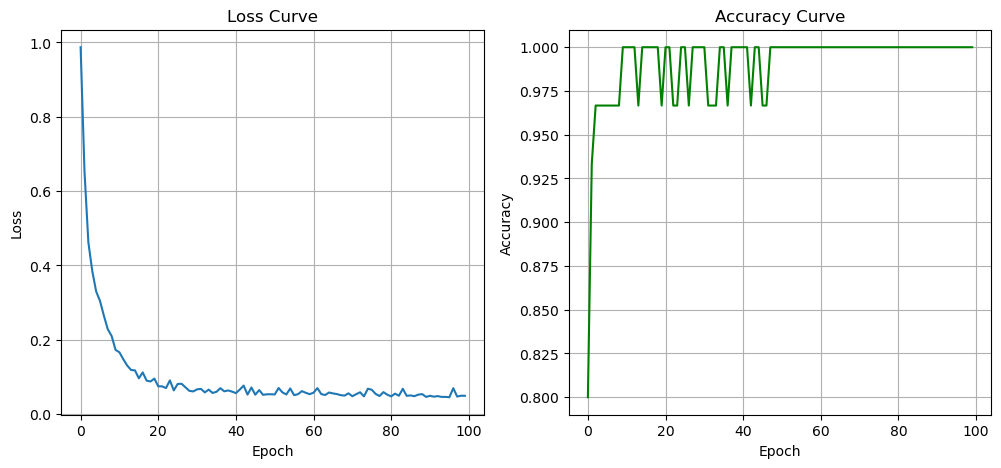


================ 임베딩 벡터 (전체 150개) ================
Shape: torch.Size([150, 4])
tensor([[-9.0068e-01,  1.0190e+00, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00, -1.3198e-01, -1.3402e+00, -1.3154e+00],
        [-1.3854e+00,  3.2841e-01, -1.3971e+00, -1.3154e+00],
        [-1.5065e+00,  9.8217e-02, -1.2834e+00, -1.3154e+00],
        [-1.0218e+00,  1.2492e+00, -1.3402e+00, -1.3154e+00],
        [-5.3718e-01,  1.9398e+00, -1.1697e+00, -1.0522e+00],
        [-1.5065e+00,  7.8881e-01, -1.3402e+00, -1.1838e+00],
        [-1.0218e+00,  7.8881e-01, -1.2834e+00, -1.3154e+00],
        [-1.7489e+00, -3.6218e-01, -1.3402e+00, -1.3154e+00],
        [-1.1430e+00,  9.8217e-02, -1.2834e+00, -1.4471e+00],
        [-5.3718e-01,  1.4794e+00, -1.2834e+00, -1.3154e+00],
        [-1.2642e+00,  7.8881e-01, -1.2266e+00, -1.3154e+00],
        [-1.2642e+00, -1.3198e-01, -1.3402e+00, -1.4471e+00],
        [-1.8700e+00, -1.3198e-01, -1.5107e+00, -1.4471e+00],
        [-5.2506e-02,  2.1700e+00, -1.4539e+00, -1.3

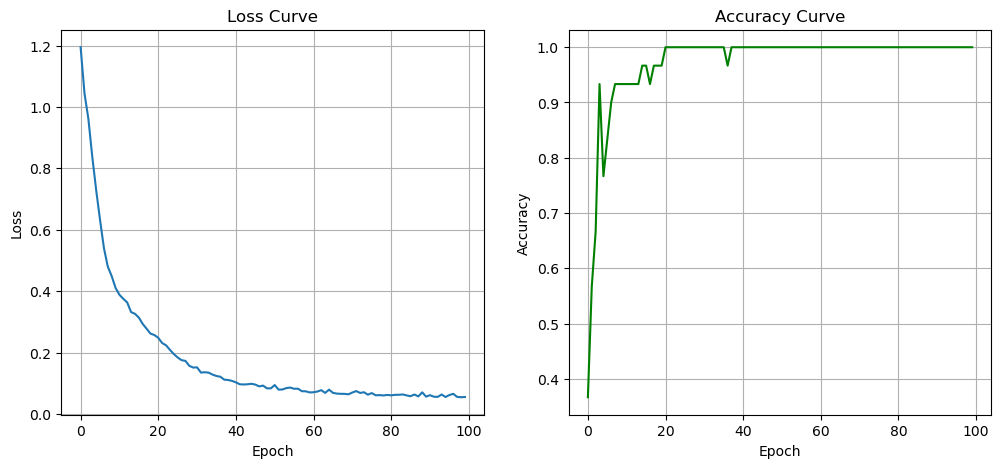


===== 전체 실험 비교 =====
[실험 1] {'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 50, 'activation': 'relu', 'final_loss': 0.05960406124358997, 'final_accuracy': 1.0}
[실험 2] {'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 100, 'activation': 'relu', 'final_loss': 0.043075984984170645, 'final_accuracy': 1.0}
[실험 3] {'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 100, 'activation': 'tanh', 'final_loss': 0.04923876526299864, 'final_accuracy': 1.0}
[실험 4] {'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 100, 'activation': 'sigmoid', 'final_loss': 0.05536717240465805, 'final_accuracy': 1.0}


In [17]:
# ===================================
#          예시 실행
# ===================================
if __name__ == "__main__":
    run_experiment(hidden_units=16, activation="relu", epochs=100)
    run_experiment(hidden_units=16, activation="tanh", epochs=100)
    run_experiment(hidden_units=16, activation="sigmoid", epochs=100)

    print("\n===== 전체 실험 비교 =====")
    for i, exp in enumerate(experiment_logs):
        print(f"[실험 {i+1}] {exp}")


## 학습데이터 관찰(임베딩 벡터 분석 유효한가 차원축소 + 군집화)
- 내 프로젝트 확률 임베딩은 너무 복잡해서 잘몰랐던것이지 유효한것은 맞는지 검증해보려고 아래 코드 실행함

원본 데이터 shape: (150, 4)


/opt/anaconda3/envs/umap_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/umap_env/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP 변환 shape: (150, 2)
DBSCAN 군집 결과: [-1  0  1  2  3  4  5]


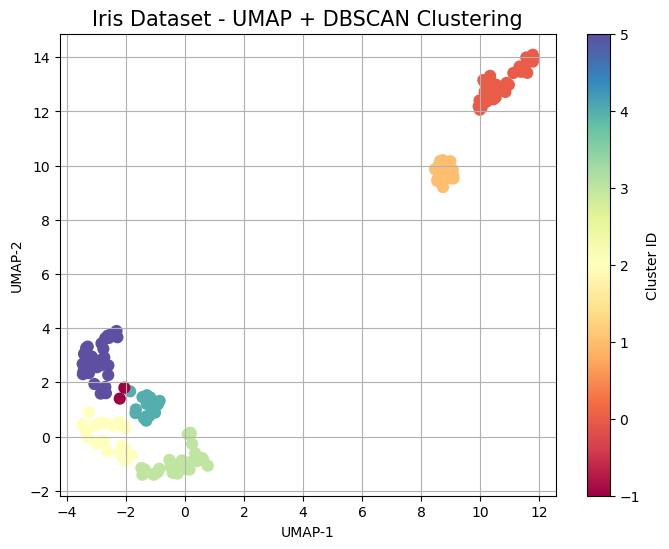

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
from sklearn.cluster import DBSCAN

# ====================================
# 1. 데이터 로드
# ====================================
iris = load_iris()
X = iris.data
y = iris.target

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("원본 데이터 shape:", X_scaled.shape)

# ====================================
# 2. UMAP으로 차원 축소 (4D → 2D)
# ====================================
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

print("UMAP 변환 shape:", X_umap.shape)

# ====================================
# 3. DBSCAN 군집화
# ====================================
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_umap)

print("DBSCAN 군집 결과:", np.unique(clusters))

# ====================================
# 4. 시각화
# ====================================
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap="Spectral", s=60)

plt.title("Iris Dataset - UMAP + DBSCAN Clustering", fontsize=15)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()


## 결과해석

 역시 그냥 기능이 좋은 두 알고리즘으로 차원축소와 군집화를 하면 임베딩벡터에 대한 정보가 눈에띠게 들어나고 각각의 클래스 3개로 나누어질줄알았는데 그냥 임베딩 거리로 눌러서 군집화하니 그렇게 효과적으로 유효하게 신경망 설계에 도움이 되지는 않네 뭔지 해석이 어려운게 마치 black box같네

Epoch 1/30 Loss=0.9683 Acc=0.8667
Epoch 11/30 Loss=0.1819 Acc=1.0000
Epoch 21/30 Loss=0.0782 Acc=1.0000
Epoch 30/30 Loss=0.0697 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 30, 'activation': 'relu', 'final_loss': 0.06973040918819606, 'final_accuracy': 1.0}



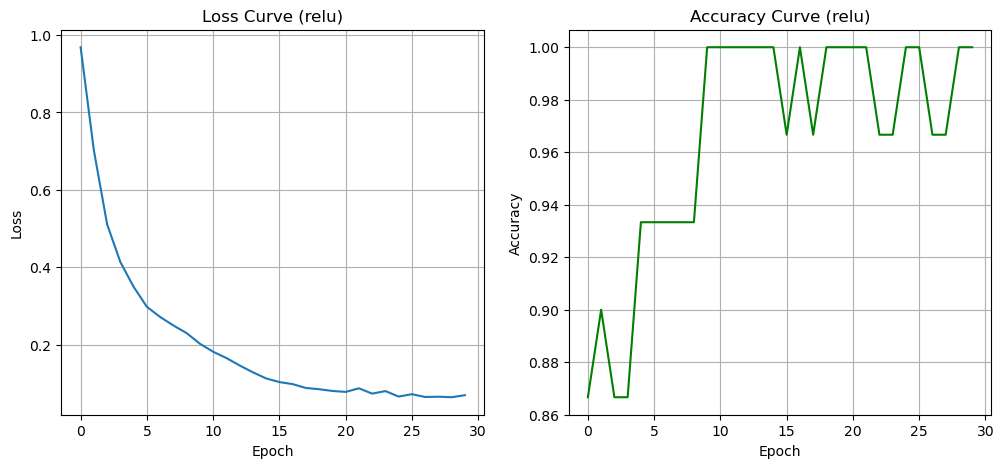

Epoch 1/200 Loss=0.9596 Acc=0.6667
Epoch 11/200 Loss=0.1325 Acc=1.0000
Epoch 21/200 Loss=0.0688 Acc=1.0000
Epoch 31/200 Loss=0.0616 Acc=1.0000
Epoch 41/200 Loss=0.0594 Acc=1.0000
Epoch 51/200 Loss=0.0519 Acc=1.0000
Epoch 61/200 Loss=0.0823 Acc=1.0000
Epoch 71/200 Loss=0.0581 Acc=1.0000
Epoch 81/200 Loss=0.0461 Acc=1.0000
Epoch 91/200 Loss=0.0441 Acc=1.0000
Epoch 101/200 Loss=0.0462 Acc=1.0000
Epoch 111/200 Loss=0.0527 Acc=1.0000
Epoch 121/200 Loss=0.0477 Acc=1.0000
Epoch 131/200 Loss=0.0438 Acc=1.0000
Epoch 141/200 Loss=0.0457 Acc=1.0000
Epoch 151/200 Loss=0.0425 Acc=1.0000
Epoch 161/200 Loss=0.0424 Acc=1.0000
Epoch 171/200 Loss=0.0643 Acc=1.0000
Epoch 181/200 Loss=0.0425 Acc=1.0000
Epoch 191/200 Loss=0.0445 Acc=1.0000
Epoch 200/200 Loss=0.0425 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 200, 'activation': 'relu', 'final_loss': 0.042508063779678196, 'final_accuracy': 1.0}



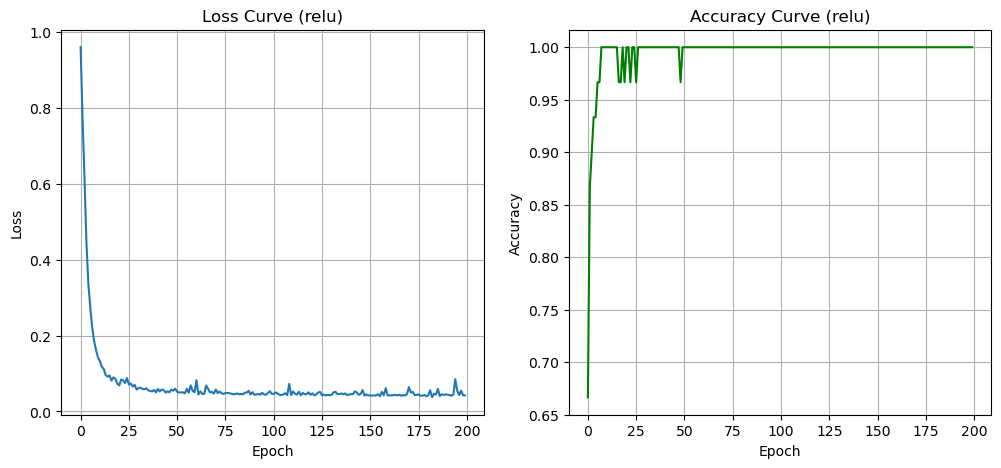

{'hidden_units': 16,
 'batch_size': 16,
 'learning_rate': 0.01,
 'epochs': 200,
 'activation': 'relu',
 'final_loss': 0.042508063779678196,
 'final_accuracy': 1.0}

In [6]:
run_experiment(epochs=30)
run_experiment(epochs=200)


Epoch 1/50 Loss=1.0341 Acc=0.6333
Epoch 11/50 Loss=0.2017 Acc=1.0000
Epoch 21/50 Loss=0.0806 Acc=1.0000
Epoch 31/50 Loss=0.0650 Acc=1.0000
Epoch 41/50 Loss=0.0708 Acc=1.0000
Epoch 50/50 Loss=0.0527 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 8, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 50, 'activation': 'relu', 'final_loss': 0.05271807452663779, 'final_accuracy': 1.0}



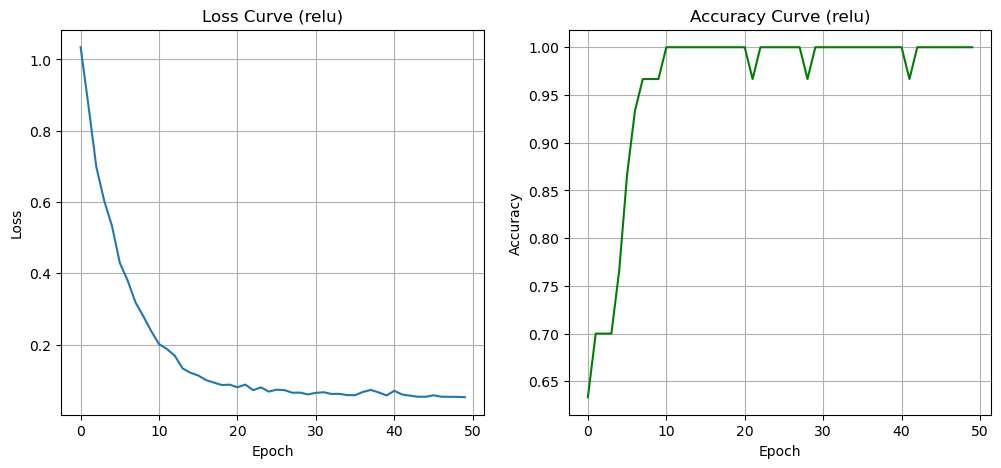

Epoch 1/50 Loss=0.7049 Acc=0.9333
Epoch 11/50 Loss=0.0806 Acc=0.9667
Epoch 21/50 Loss=0.0552 Acc=1.0000
Epoch 31/50 Loss=0.0514 Acc=1.0000
Epoch 41/50 Loss=0.0455 Acc=1.0000
Epoch 50/50 Loss=0.0447 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 64, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 50, 'activation': 'relu', 'final_loss': 0.04472534597152844, 'final_accuracy': 1.0}



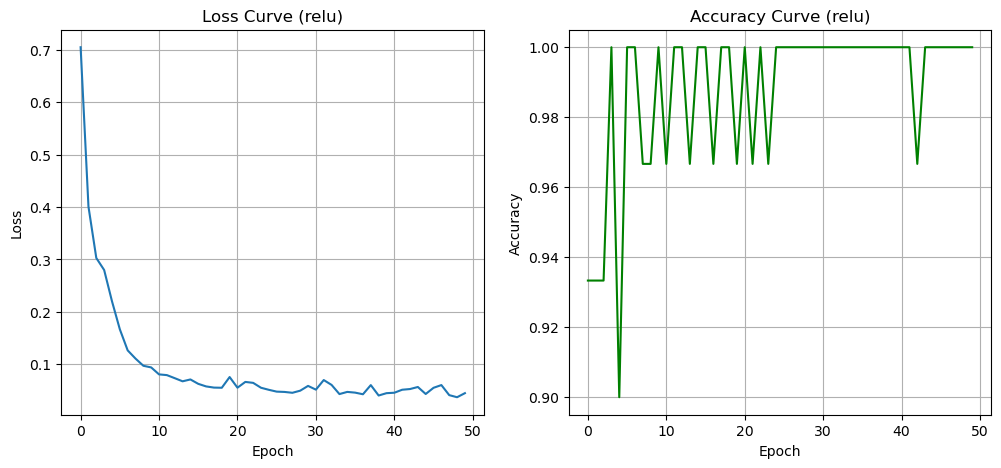

{'hidden_units': 64,
 'batch_size': 16,
 'learning_rate': 0.01,
 'epochs': 50,
 'activation': 'relu',
 'final_loss': 0.04472534597152844,
 'final_accuracy': 1.0}

In [7]:
run_experiment(hidden_units=8)
run_experiment(hidden_units=64)


Epoch 1/100 Loss=0.6421 Acc=0.8333
Epoch 11/100 Loss=0.0784 Acc=0.9667
Epoch 21/100 Loss=0.0671 Acc=1.0000
Epoch 31/100 Loss=0.0699 Acc=0.9667
Epoch 41/100 Loss=0.0642 Acc=1.0000
Epoch 51/100 Loss=0.0600 Acc=1.0000
Epoch 61/100 Loss=0.0630 Acc=1.0000
Epoch 71/100 Loss=0.0490 Acc=1.0000
Epoch 81/100 Loss=0.0663 Acc=1.0000
Epoch 91/100 Loss=0.0592 Acc=1.0000
Epoch 100/100 Loss=0.0569 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 16, 'batch_size': 4, 'learning_rate': 0.01, 'epochs': 100, 'activation': 'relu', 'final_loss': 0.056868700765486814, 'final_accuracy': 1.0}



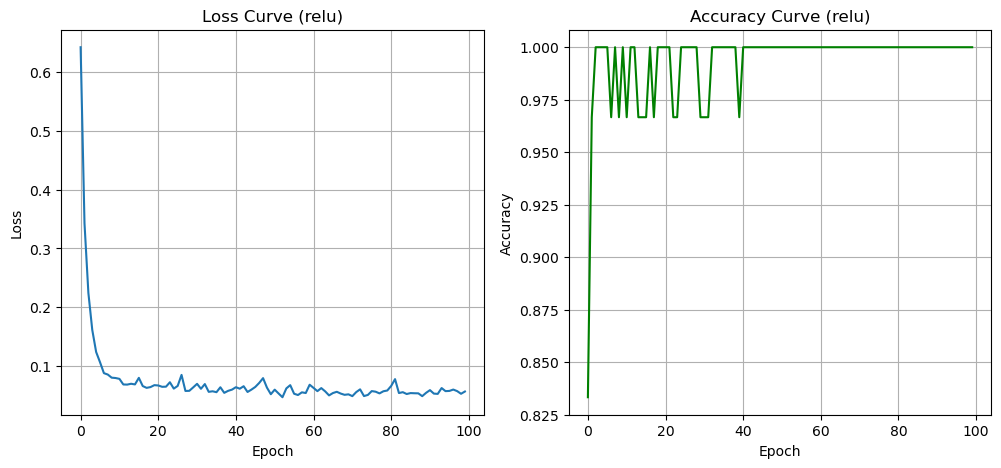

Epoch 1/100 Loss=1.1614 Acc=0.5000
Epoch 11/100 Loss=0.3183 Acc=0.9333
Epoch 21/100 Loss=0.1565 Acc=1.0000
Epoch 31/100 Loss=0.0866 Acc=1.0000
Epoch 41/100 Loss=0.0670 Acc=0.9667
Epoch 51/100 Loss=0.0575 Acc=0.9667
Epoch 61/100 Loss=0.0598 Acc=1.0000
Epoch 71/100 Loss=0.0532 Acc=1.0000
Epoch 81/100 Loss=0.0535 Acc=1.0000
Epoch 91/100 Loss=0.0534 Acc=1.0000
Epoch 100/100 Loss=0.0530 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 16, 'batch_size': 32, 'learning_rate': 0.01, 'epochs': 100, 'activation': 'relu', 'final_loss': 0.0529918959364295, 'final_accuracy': 1.0}



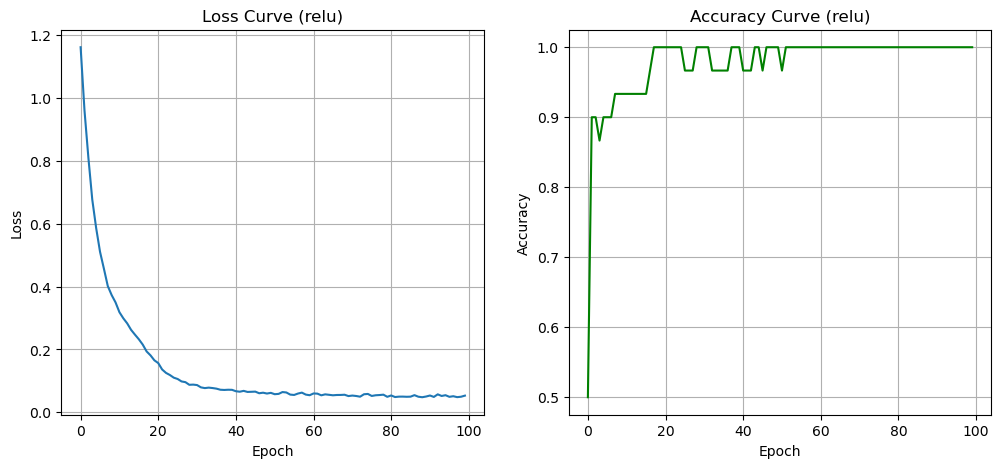

{'hidden_units': 16,
 'batch_size': 32,
 'learning_rate': 0.01,
 'epochs': 100,
 'activation': 'relu',
 'final_loss': 0.0529918959364295,
 'final_accuracy': 1.0}

In [11]:
run_experiment(batch_size=4, epochs =100)
run_experiment(batch_size=32, epochs = 100)


Epoch 1/50 Loss=1.0238 Acc=0.6333
Epoch 11/50 Loss=0.1937 Acc=1.0000
Epoch 21/50 Loss=0.0997 Acc=1.0000
Epoch 31/50 Loss=0.0607 Acc=1.0000
Epoch 41/50 Loss=0.0610 Acc=1.0000
Epoch 50/50 Loss=0.0489 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 50, 'activation': 'relu', 'final_loss': 0.048936514533124864, 'final_accuracy': 1.0}



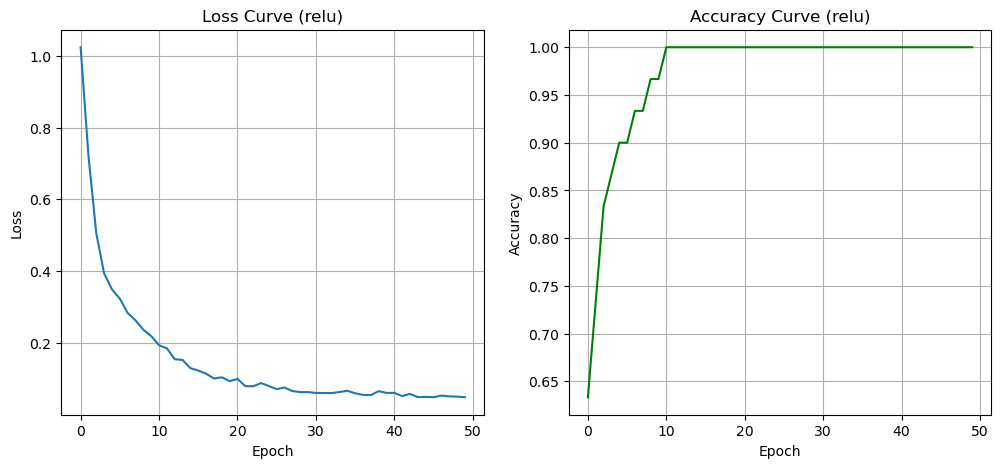

Epoch 1/50 Loss=0.8179 Acc=0.8000
Epoch 11/50 Loss=0.1318 Acc=1.0000
Epoch 21/50 Loss=0.0733 Acc=0.9667
Epoch 31/50 Loss=0.0685 Acc=1.0000
Epoch 41/50 Loss=0.0717 Acc=1.0000
Epoch 50/50 Loss=0.0499 Acc=1.0000

===== 실험 결과 =====
{'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 50, 'activation': 'tanh', 'final_loss': 0.04989769967505708, 'final_accuracy': 1.0}



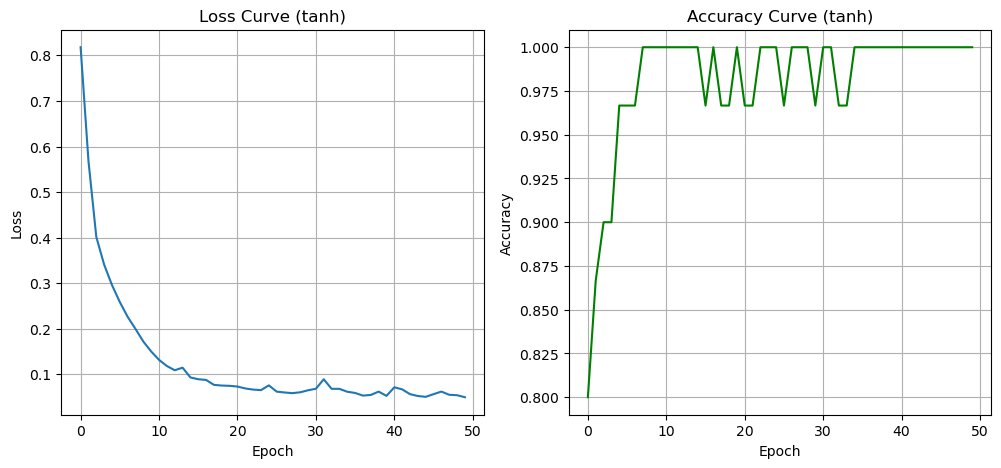

Epoch 1/50 Loss=1.1054 Acc=0.6333
Epoch 11/50 Loss=0.3837 Acc=0.9333
Epoch 21/50 Loss=0.2424 Acc=0.9667
Epoch 31/50 Loss=0.1472 Acc=1.0000
Epoch 41/50 Loss=0.1014 Acc=1.0000
Epoch 50/50 Loss=0.0883 Acc=0.9667

===== 실험 결과 =====
{'hidden_units': 16, 'batch_size': 16, 'learning_rate': 0.01, 'epochs': 50, 'activation': 'sigmoid', 'final_loss': 0.0883145872503519, 'final_accuracy': 0.9666666666666667}



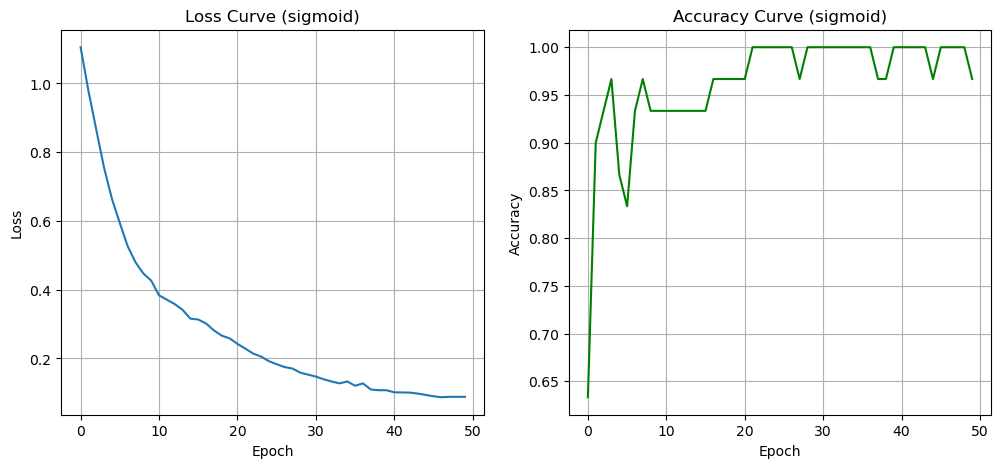

{'hidden_units': 16,
 'batch_size': 16,
 'learning_rate': 0.01,
 'epochs': 50,
 'activation': 'sigmoid',
 'final_loss': 0.0883145872503519,
 'final_accuracy': 0.9666666666666667}

In [12]:
run_experiment(activation="relu")
run_experiment(activation="tanh")
run_experiment(activation="sigmoid")


# XOR문제 간단한 문제를 통해 파라미터와 입력값 어떻게 변화하며 학습되는지 내부 자세히 보기

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 정의 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)    # 2 → 2
        self.act1 = nn.Tanh()         # 비선형성
        self.fc2 = nn.Linear(2, 1)    # 2 → 1
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))   # 은닉층
        out = self.act2(self.fc2(h)) # 출력층
        return out, h

model = XORNet()


# ====== 3. 손실함수 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 학습 기록 저장 공간 ======
log = {
    "epoch": [],
    "W1": [], "b1": [],
    "W2": [], "b2": [],
    "hidden": [],       # 은닉층 출력
    "y_hat": [],        # 예측값
    "loss": [],
}


# ====== 5. 학습 ======
epochs = 5000
for epoch in range(epochs):

    # ===== Forward =====
    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    # ===== Backward =====
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ===== 학습 기록 저장 =====
    if epoch % 100 == 0:      # 100epoch마다 기록 (원하면 1로 바꿔도 됨)
        W1 = model.fc1.weight.data.clone()
        b1 = model.fc1.bias.data.clone()
        W2 = model.fc2.weight.data.clone()
        b2 = model.fc2.bias.data.clone()

        log["epoch"].append(epoch)
        log["W1"].append(W1)
        log["b1"].append(b1)
        log["W2"].append(W2)
        log["b2"].append(b2)
        log["hidden"].append(hidden.data.clone())
        log["y_hat"].append(y_hat.data.clone())
        log["loss"].append(loss.item())

        print(f"Epoch {epoch}")
        print(" W1:", W1)
        print(" b1:", b1)
        print(" W2:", W2)
        print(" b2:", b2)
        print(" Hidden Layer Output:\n", hidden.data)
        print(" y_hat:\n", y_hat.data)
        print(" Loss:", loss.item())
        print("-"*40)


# ====== 6. 마지막 결과 ======
print("\nFinal Prediction:")
final_y, final_h = model(X)
print("Input  :", X)
print("Hidden :", final_h.data)
print("Output :", final_y.data)
print("Loss   :", criterion(final_y, y).item())


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록 (매 epoch 저장)
    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 시각화 ======
plt.figure(figsize=(15, 10))

# ---- (1) Loss 그래프 ----
plt.subplot(2, 2, 1)
plt.plot(log_loss)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ---- (2) W1 변화 ----
W1_arr = torch.tensor(log_W1).numpy()  # (epochs, 2, 2)
plt.subplot(2, 2, 2)
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.title("Hidden Layer Weights (W1)")
plt.xlabel("Epoch")
plt.legend()

# ---- (3) W2 변화 ----
W2_arr = torch.tensor(log_W2).numpy()  # (epochs, 1, 2)
plt.subplot(2, 2, 3)
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.title("Output Layer Weights (W2)")
plt.xlabel("Epoch")
plt.legend()

# ---- (4) 출력값 변화 ----
yhat_arr = torch.tensor(log_yhat).numpy()  # (epochs, 4, 1)
plt.subplot(2, 2, 4)
plt.plot(yhat_arr[:,0,0], label="y_hat(0,0)")
plt.plot(yhat_arr[:,1,0], label="y_hat(0,1)")
plt.plot(yhat_arr[:,2,0], label="y_hat(1,0)")
plt.plot(yhat_arr[:,3,0], label="y_hat(1,1)")
plt.title("Prediction Change per Input")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


# ====== 7. 최종결과 ======
final_y, final_h = model(X)
print("Final Output:\n", final_y)
print("Final Hidden:\n", final_h)
print("Final Loss:", criterion(final_y, y).item())
